In [1]:
#import libraries
import numpy as np
import re
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/FYP')

Mounted at /content/FYP


In [3]:
# load dataset
file_path = '/content/FYP/MyDrive/FYP/NWP_dzongkha/Dataset20k.xlsx'


# Load the Excel file into a DataFrame
df = pd.read_excel(file_path, sheet_name='Sheet1', usecols=['Dzongkha'])

# Extract the text data from a specific column (e.g., 'Dzongkha')
text = df['Dzongkha'].to_string(index=False)
print(text)

                         ང་ སྡོད་ ས་ ནཱ་ ལུ་ ཨིན །
          བྱི་ལི་ འདི་ # ཡིད་ཁར་འོང་ཏོག་ཏོ་ འདུག །
                          བྱི་ལི་ འདི་ མ་ ཤི་ བས །
                            བྱི་ལི་ འདི་ ཉལ་ ནུག །
                           རྐང་ཁྲི་ འདི་ ཆག་ ནུག །
རྒྱབ་སྐྱོར་ གྱི་ སྐད་ རྐྱབ་ ནི་ འདི་ # མཚམས་འཇོ...
                     གདམ་ཁ་ འདི་ # ཁྱོད་ ལུ་ ཡོད །
                      ང་ ལཱ་ འབད་ ས་ ནཱ་ ལུ་ ཨིན །
     དེ་འབདཝ་ལས་ # ང་ གིས་ བརྒྱུད་འཕྲིན་ བཏང་ ཡི །
                   དེ་འབདཝ་ལས་ # ང་ གིས་ འབད་ ཡི །
                    དེ་འབདཝ་ལས་ # ང་ མི་ ཁོམ་ པས །
                   དེ་འབདཝ་ལས་ # ང་ ནཱ་ སྡོད་ ཡི །
                  དེ་འབདཝ་ལས་ # ང་ འཕྱིས་ སོ་ ཡི །
               དེ་འབདཝ་ལས་ # རྡོ་རྗེ་ ཡར་ སོ་ ཡི །
             དེ་འབདཝ་ལས་ # རྡོ་རྗེ་ གིས་ བཞག་ ཡི །
                ནཱི་ ཁྱོད་ ཀྱི་ བསམ་འཆར་ ཨིན་ པས །
                 རྒྱང་མཐོང་ # མེདཔ་ ཤོར་ སོ་ ནུག །
               ཨ་ལུ་ # ཁུ་སིམ་སི་ སྦེ་ སྡོད་ ནུག །
                            ཨ་ལུ་ གཉིད་ ལོག་ ནུག །
                              ད

# Preprocessing

In [4]:
# Preprocessing the text
text = re.sub(r'[a-zA-Z0-9]', '', text)
text = text.replace('#', '')
text = text.replace('?', '')
text = text.replace('།', '')
#Removing tsa after the word
text = text.replace(' ', '$')
text = text.replace('་$', '$་')
text = text.replace('$$', '')
text = text.replace('$', ' ')
text = text.replace('་ ', '')
text = text.replace(' ་', ' ')
# print(text)

In [5]:
# Tokenize the words
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
lines = text.split('\n')

In [6]:
# Tokenize and form n-grams for each line separately
input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)
print(n_gram_sequence)
print(input_sequences)

Output hidden; open in https://colab.research.google.com to view.

In [7]:
#input sequences are padded to have same length
max_sequence_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))


In [8]:
input_sequences

array([[   0,    0,    0, ...,    0,    1,   34],
       [   0,    0,    0, ...,    1,   34,   97],
       [   0,    0,    0, ...,   34,   97,   65],
       ...,
       [   0,    0,    0, ..., 2055,   94,   76],
       [   0,    0,    0, ...,   94,   76,   20],
       [   0,    0,    0, ...,   76,   20, 8063]], dtype=int32)

In [9]:
max_sequence_len

12

In [10]:
print(n_gram_sequence)

[10, 2, 2055, 94, 76, 20, 8063]


In [11]:
# Split sequences into input and output
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [12]:
# Convert y to one-hot encoding
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

In [13]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
!nvidia-smi

Fri Dec 15 10:24:04 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   57C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Building the model

In [15]:
# Build the BiLSTM model
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len - 1))
model.add(Bidirectional(LSTM(200)))  # Wrap LSTM with Bidirectional
model.add(Dense(total_words, activation='softmax'))

In [16]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
# Define checkpoint to save best model and the last model
checkpoint_path_best = "/content/FYP/MyDrive/FYP/NWP_dzongkha/model_checkpoint_best.h5"
checkpoint_path_last = "/content/FYP/MyDrive/FYP/NWP_dzongkha/model_checkpoint_last.h5"

checkpoint_best = ModelCheckpoint(checkpoint_path_best, monitor='val_loss', save_best_only=True, mode='min')
checkpoint_last = ModelCheckpoint(checkpoint_path_last, save_weights_only=False, save_freq='epoch')

In [18]:
# # Load the best model
# best_model = load_model('model_checkpoint_best.h5')

# # Load the last model
# last_model = load_model('model_checkpoint_last.h5')

#Model Training

In [19]:
# Train the model with a larger batch size and more epochs
batch_size = 64
epochs = 200
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_best, checkpoint_last]  # Include the checkpoint callback
)

Epoch 1/200
1319/1319 [==============================] - ETA: 0s - loss: 5.8764 - accuracy: 0.0959

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1319/1319 [==============================] - 39s 24ms/step - loss: 5.8764 - accuracy: 0.0959 - val_loss: 5.3352 - val_accuracy: 0.1562
Epoch 2/200
1319/1319 [==============================] - 18s 14ms/step - loss: 4.9569 - accuracy: 0.1856 - val_loss: 5.0660 - val_accuracy: 0.1987
Epoch 3/200
1319/1319 [==============================] - 21s 16ms/step - loss: 4.4913 - accuracy: 0.2272 - val_loss: 4.9562 - val_accuracy: 0.2170
Epoch 4/200
1319/1319 [==============================] - 17s 13ms/step - loss: 4.1263 - accuracy: 0.2573 - val_loss: 4.9336 - val_accuracy: 0.2302
Epoch 5/200
1319/1319 [==============================] - 16s 12ms/step - loss: 3.8218 - accuracy: 0.2843 - val_loss: 4.9651 - val_accuracy: 0.2345
Epoch 6/200
1319/1319 [==============================] - 16s 12ms/step - loss: 3.5449 - accuracy: 0.3117 - val_loss: 5.0261 - val_accuracy: 0.2359
Epoch 7/200
1319/1319 [==============================] - 15s 11ms/step - loss: 3.2992 - accuracy: 0.3410 - val_loss: 5.0801 - val_

# Saving the model

In [22]:
#save the model
model.save('/content/FYP/MyDrive/FYP/NWP_dzongkha/Final_Models/20k_v1_Bi-LSTM.h5')

In [23]:
# Save the Tokenizer
import json
tokenizer_file_path = '/content/FYP/MyDrive/FYP/NWP_dzongkha/Final_Models/20k_v1_Bi-LSTM_tokenizer.json'
tokenizer_json = tokenizer.to_json()

with open(tokenizer_file_path, 'w', encoding='utf-8') as f:
    f.write(tokenizer_json)

# Analysis

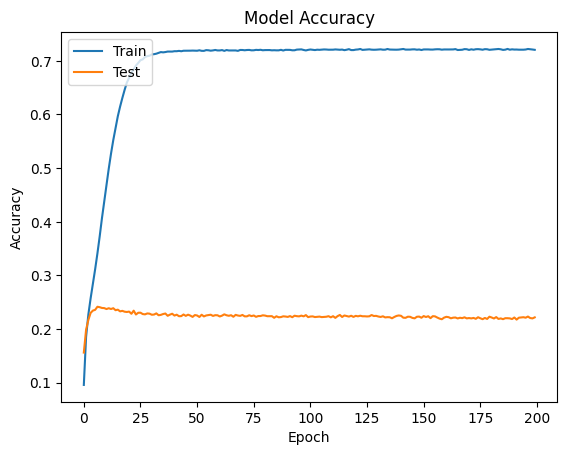

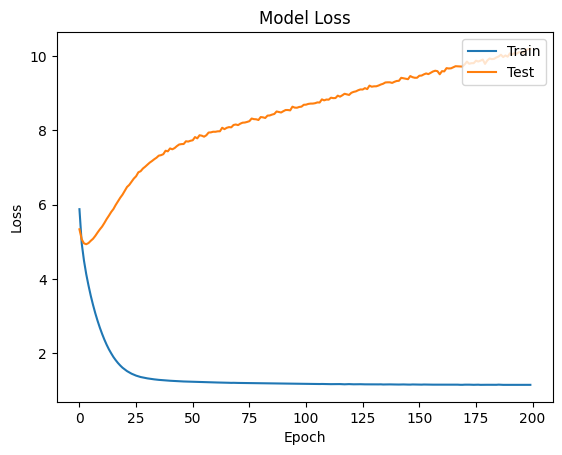

In [24]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot the training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

# Testing

In [25]:
seed_text = input("Input the seed text: ")
next_words_text = 1
next_words = int(next_words_text)

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted_probs = model.predict(token_list)

    # Get the top N predictions
    top_n = 10  # You can adjust the number of top predictions as needed
    top_indices = predicted_probs[0].argsort()[-top_n:][::-1]

    # Create a list of words corresponding to the top indices
    top_words = [word for word, index in tokenizer.word_index.items() if index in top_indices]

    # Output the top predicted words
    print("Top Predicted Words:", top_words)

Input the seed text: ང་ སྡོད་ 
1/1 [==============================] - 1s 688ms/step
Top Predicted Words: ['འདི', 'ལུ', 'ཁྱོད', 'ཚུ', 'ག་དེམ་ཅིག', 'ཆུང་ཀུ', 'འབྱང', 'བསྒྱུར་བཅོས', 'ག་རའི', 'ཟླ']
